In [1]:
import pandas as pd

train = pd.read_parquet("../data/raw/train.parquet")
valid = pd.read_parquet("../data/raw/validation.parquet")
test = pd.read_parquet("../data/raw/test.parquet")

In [2]:
print(train.shape)
print(valid.shape)
print(test.shape)

(1578, 8)
(395, 8)
(494, 8)


In [3]:
train.columns

Index(['O', 'C', 'E', 'A', 'N', 'ptype', 'text', '__index_level_0__'], dtype='object')

In [4]:
train.head()

,O,C,E,A,N,ptype,text,__index_level_0__
0,1,0,0,1,1,19,it is wednesday. I can't wait until friday bec...,774
1,1,1,1,0,1,29,"wow, I want to go talk to the socialist organi...",178
2,1,0,1,1,0,22,"I wish polygamy was still legal. Well, not pol...",1881
3,1,0,1,0,0,20,"Well, lets see . . . I guess the foremost thin...",1563
4,0,1,0,1,1,11,College? I wonder how it will be? I just ...,1594


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1578 entries, 0 to 1577
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   O                  1578 non-null   object
 1   C                  1578 non-null   object
 2   E                  1578 non-null   object
 3   A                  1578 non-null   object
 4   N                  1578 non-null   object
 5   ptype              1578 non-null   object
 6   text               1578 non-null   object
 7   __index_level_0__  1578 non-null   int64 
dtypes: int64(1), object(7)
memory usage: 98.8+ KB


In [6]:
train["ptype"].value_counts()

ptype
30    121
1      90
14     86
17     86
22     58
9      57
10     57
21     51
3      50
31     46
23     46
18     46
26     46
19     46
28     46
11     46
6      46
15     46
12     46
29     44
5      43
25     40
20     40
0      38
16     38
7      34
2      34
13     34
24     30
4      30
27     29
8      28
Name: count, dtype: int64

In [7]:
for col in ["O", "C", "E", "A", "N"]:
    print(col)
    print(train[col].value_counts())
    print()

O
O
1    813
0    765
Name: count, dtype: int64

C
C
1    802
0    776
Name: count, dtype: int64

E
E
1    817
0    761
Name: count, dtype: int64

A
A
1    837
0    741
Name: count, dtype: int64

N
N
0    790
1    788
Name: count, dtype: int64



In [11]:
# Length of each essay
train["TEXT_LENGTH"] = train["text"].str.len()

train["TEXT_LENGTH"].describe()

count     1578.000000
mean      3314.888466
std       1291.807792
min        217.000000
25%       2421.750000
50%       3171.000000
75%       4106.750000
max      12852.000000
Name: TEXT_LENGTH, dtype: float64

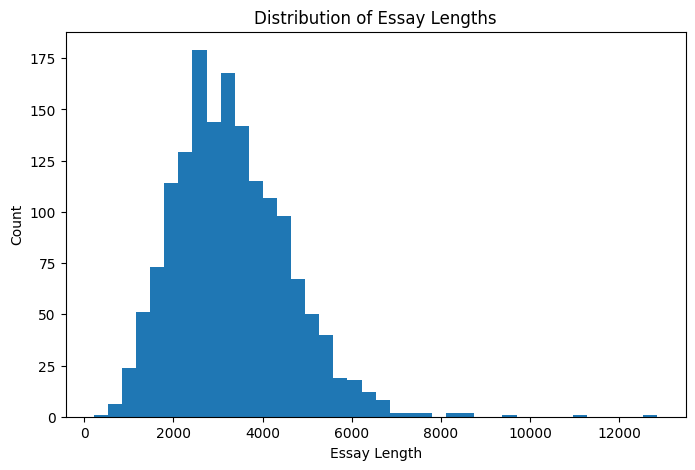

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(train["TEXT_LENGTH"], bins=40)
plt.xlabel("Essay Length")
plt.ylabel("Count")
plt.title("Distribution of Essay Lengths")
plt.show()

In [15]:
train.duplicated(subset="text").sum()

np.int64(0)

In [16]:
corr = train[["O","C","E","A","N"]].corr()

corr

,O,C,E,A,N
O,1.000000,-0.028402,0.078855,0.017201,-0.045610
C,-0.028402,1.000000,0.136402,0.131071,-0.148288
E,0.078855,0.136402,1.000000,0.126164,-0.162288
A,0.017201,0.131071,0.126164,1.000000,-0.190390
N,-0.045610,-0.148288,-0.162288,-0.190390,1.000000


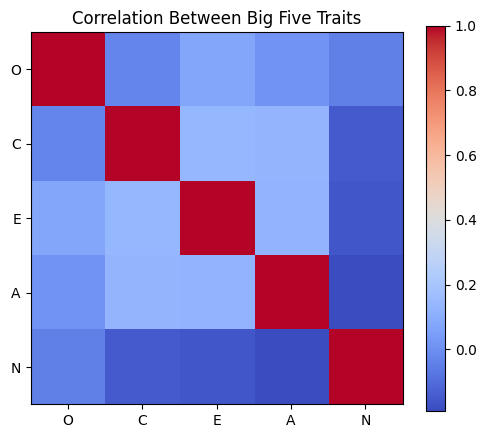

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Between Big Five Traits")
plt.show()